<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">


**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

##  Airbnb Price Prediction Pipeline
### *End-to-End MLOps Architecture with PyCaret & LightGBM*
---


DOCENTE:<br>
Oscar Nicolas Gomez Giraldo<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela


Mayo 2026


---

#  **Desarrollo de un Pipeline End-to-End bajo Estándares MLOps para la Predicción de Precios de Alojamiento en Airbnb**

#  Introducción y Objetivos del Proyecto

## 1. Introducción
En la actualidad, la valoración y predicción de precios en el mercado de alojamiento turístico, liderado por plataformas como Airbnb, representa un desafío de alta complejidad debido a la naturaleza heterogénea y masiva de sus datos. Los datasets de este sector combinan variables numéricas, registros de alta cardinalidad (como la ubicación por barrios o tipos de propiedad) y campos binarios altamente correlacionados. Tradicionalmente, los modelos de Machine Learning se desarrollan en entornos de experimentación aislados; sin embargo, el verdadero valor de estos modelos se despliega cuando logran integrarse de manera ágil, consistente y escalable en entornos de producción.

El presente trabajo aborda el diseño, desarrollo e implementación de un pipeline end-to-end de Machine Learning enfocado en la predicción del precio de alojamientos de Airbnb. Utilizando principios avanzados de **MLOps (Machine Learning Operations)** y la librería Scikit-Learn, este proyecto se enfoca en resolver los problemas estructurales más comunes en el despliegue de software predictivo: el acoplamiento de código, la inconsistencia de los tipos de datos (*data dtypes*), el manejo defensivo de valores faltantes y el sesgo estadístico de las variables.

A través de la creación de transformadores modulares personalizados y la estructuración de una arquitectura de software limpia en carriles paralelos, este sistema garantiza que los datos crudos del negocio se limpien, agrupen y transformen de manera idéntica tanto en la fase de entrenamiento del algoritmo como en la fase de inferencia en tiempo real a través de una API.

Una vez que el set de datos está blindado por esta capa defensiva, entra en juego **PyCaret**, una librería de Machine Learning de bajo código (*low-code*) diseñada para optimizar los ciclos de experimentación y despliegue empresarial. 

La gran ventaja competitiva de nuestra arquitectura radica en que **PyCaret no sustituye nuestro trabajo de ingeniería de software, sino que lo potencia**. Mediante su función central `setup()`, el entorno asimila e inyecta nuestros transformadores personalizados (`Custom pipeline: Yes`) como la primera línea de ejecución del flujo. 

Esto significa que cuando PyCaret realiza tareas avanzadas como la partición balanceada de datos (*Train/Test Split*), la imputación final de nulos remanentes, y la validación cruzada estratificada (*10-Fold Cross Validation*), lo hace **respetando el aislamiento de los datos (*Data Leakage Prevention*)** definido en nuestras clases de Python. Esta fusión garantiza que el pipeline completo pueda ser exportado como un único artefacto binario listo para ser consumido por un microservicio, garantizando una transición impecable del entorno de desarrollo al entorno productivo.



---

## 2. Objetivos

###  Objetivo General
Diseñar e implementar un pipeline de preprocesamiento y modelado predictivo automatizado bajo estándares de MLOps, utilizando Scikit-Learn y Python, para estimar de forma precisa el precio de alojamientos de Airbnb y asegurar su viabilidad técnica para ser consumido a través de una API en producción.

###  Objetivos Específicos
* **Desarrollar componentes de software modular:** Crear e integrar transformadores personalizados (`TargetCleaner`, `BinaryTransformer` y `TextGroupingTransformer`) basados en las clases nativas de Scikit-Learn, garantizando el aislamiento de operaciones y la reutilización del código.
* **Controlar la alta cardinalidad y suciedad de los datos:** Implementar un algoritmo de agrupación por umbral (*threshold*) estadístico que optimice las variables de texto y reduzca la explosión de dimensiones provocada por variables críticas como las zonas geográficas o los tipos de propiedades.
* **Asegurar la consistencia metodológica (Anti-Data Leakage):** Estructurar un flujo secuencial y en paralelo mediante `ColumnTransformer` y `Pipeline` que memorice los parámetros estadísticos del entrenamiento (como medianas y categorías permitidas) para replicarlos de forma exacta en la fase de inferencia.
* **Optimizar la variable objetivo para modelos estadísticos:** Aplicar transformaciones logarítmicas de manera automatizada acopladas al regresor final mediante `TransformedTargetRegressor`, permitiendo que el modelo trabaje en escalas estadísticas óptimas pero devuelva predicciones en la moneda real del negocio.
* **Preparar el sistema para un despliegue en producción (MLOps ready):** Construir un script central de entrenamiento (`train.py`) ubicado estratégicamente en la raíz del proyecto que automatice el flujo de datos y exporte un único artefacto serializado listo para ser montado en un microservicio con FastAPI.

## **Variables eliminadas**

- `id`, `host_id`, `scrape_id`: Identificadores numéricos únicos que no aportan patrones estadísticos.
- `listing_url`, `host_url`: Enlaces externos que no contienen información procesable para el cálculo del precio.
- `thumbnail_url`, `medium_url`, `picture_url`, `xl_picture_url`, `host_thumbnail_url`, `host_picture_url`: Recursos multimedia que requieren visión artificial y no aportan valor como texto plano.
- `name`, `summary`, `space`, `description`, `neighborhood_overview`, `notes`, `transit`, `access`, `interaction`, `house_rules`, `host_about`: Texto libre no estructurado que genera ruido sin un procesamiento avanzado de NLP.
- `host_name`, `host_location`, `host_neighbourhood`: Datos biográficos o geográficos con alta cardinalidad y redundantes frente a las coordenadas exactas.
- `street`, `zipcode`, `market`, `smart_location`: Información de ubicación con formato inconsistente y ruido textual.
- `city`, `state`, `country_code`, `country`, `jurisdiction_names`: Variables de baja varianza o constantes que no ayudan al modelo a diferenciar precios.
- `weekly_price`, `monthly_price`: Riesgo de **Data Leakage** (fuga de datos), ya que están directamente relacionadas con la variable objetivo.
- `square_feet`: Históricamente presenta una altísima cantidad de valores nulos (NaN).
- `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`: Variables calculadas por Airbnb que presentan alta colinealidad con `minimum_nights`.
- `last_scraped`, `calendar_last_scraped`, `calendar_updated`: Metadatos técnicos del proceso de extracción sin impacto en el valor del alojamiento.
- `has_availability`, `experiences_offered`, `is_business_travel_ready`: Variables con valores casi constantes que no permiten segmentar el precio de forma efectiva.
- `requires_license`, `license`: Información administrativa con exceso de valores nulos y nula influencia en la dinámica de precios del mercado.
- `host_total_listings_count`, `host_listings_count`: Redundantes frente a `calculated_host_listings_count`, la cual suele ser más precisa.
- `require_guest_profile_picture`, `require_guest_phone_verification`: Políticas del anfitrión que influyen en la seguridad, pero raramente impactan el precio por noche.
- `host_acceptance_rate`: Variable con todas las filas con valores nulos.
- `amenities` : Muchas amenities no afectan el precio ni la demanda.
- `review_scores_accuracy`, `review_scores_cleanliness`,`review_scores_cleanliness`, `review_scores_checkin`, etc, todas se resumen en review_score_rating.
- `bed_type`, falta de varianza (Dominancia de una sola categoría).
- `cleaning_fee`, `security_deposit`: variables con mas del 35% de valores faltantes

## **Carga de librerias y datos:**

In [ ]:
# =========================
# Standard library imports
# =========================
import os
import sys

# =========================
# Third-party imports
# =========================
import hydra
import numpy as np
import pandas as pd

from hydra import compose, initialize

# IMPORTA PRIMERO PYCARET
# (Para que tome el control de su versión de antlr4)
from pycaret.regression import *

from lightgbm import LGBMRegressor

from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


ImportError: cannot import name '_print_elapsed_time' from 'sklearn.utils' (c:\Users\ACER\AppData\Local\pypoetry\Cache\virtualenvs\airbnb-LqLozEwC-py3.11\Lib\site-packages\sklearn\utils\__init__.py)

: 

## **CARGA DE DATOS**

In [2]:
# 1. Limpiar cualquier instancia previa de Hydra 
hydra.core.global_hydra.GlobalHydra.instance().clear()

# 2. Inicializar Hydra apuntando a tu carpeta de configuración
with initialize(version_base=None, config_path="../config"):
    
    # 3. Cargar la configuración 
    cfg = compose(config_name="config")

# 4. extraer las columnas
text_features = list(cfg.features.text)
numeric_features = list(cfg.features.numeric)
binary_features = list(cfg.features.binary)
target = cfg.target

cols_to_read = text_features + numeric_features + binary_features + [target]

# 5. Leer y mostrar el DataFrame
df = pd.read_csv(
    cfg.data.path,
    usecols=cols_to_read
)

df.head()


,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,guests_included,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable
0,t,Copacabana,Condominium,Entire home/apt,5,1.0,2.0,2.0,$332.00,2,4,243,93.0,t
1,f,Copacabana,Apartment,Entire home/apt,2,1.0,1.0,2.0,$160.00,2,7,235,94.0,f
2,t,Ipanema,Apartment,Entire home/apt,3,1.0,1.0,2.0,$273.00,2,2,271,96.0,t
3,t,Ipanema,Apartment,Entire home/apt,3,1.5,1.0,2.0,$378.00,2,2,169,94.0,f
4,t,Copacabana,Loft,Entire home/apt,2,1.0,1.0,1.0,$130.00,2,3,316,98.0,f


In [3]:
# 1. Añadir la raíz del proyecto al path de Python
sys.path.append(os.path.abspath(".."))

# 2. importar  función 
from src.plots.plots import generar_diccionario

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE, VALORES UNICOS, % DE NULOS Y MODA-------



,Variable,Tipo pandas,Cantidad de valores únicos,% Valores faltantes,Valor más frecuente (Moda)
0,host_is_superhost,object,2,0.06,f
1,neighbourhood_cleansed,object,153,0.00,Copacabana
2,property_type,object,37,0.00,Apartment
3,room_type,object,4,0.00,Entire home/apt
4,accommodates,int64,22,0.00,4
5,bathrooms,float64,33,0.16,1.0
6,bedrooms,float64,17,0.12,1.0
7,beds,float64,38,0.14,1.0
8,price,object,856,0.00,$202.00
9,guests_included,int64,21,0.00,1


## **Variable target (Price)**

**Resumen de Procesamiento: Variable Objetivo (`target`) y Transformación Logarítmica**

En esta sección se preparó la variable objetivo (`price`) para el modelo de Machine Learning, aplicando técnicas de normalización y estabilización estadística para mejorar la capacidad predictiva del algoritmo.

**1. Limpieza y Tipificación de Datos**
El precio original en los datos crudos de Airbnb se registraba como una cadena de texto (tipo *object*) debido a la presencia de símbolos monetarios y separadores de miles (ej. `$180,000`). Se aplicó un preprocesamiento defensivo para:
* Buscar y eliminar valores `$0`.
* Eliminar caracteres especiales (`$`, `,`) y espacios en blanco.
* Forzar el casteo a tipo de dato numérico continuo (**punto flotante**).
* Gestionar de forma segura valores nulos o inconsistentes ($\le 0$) asignándoles un valor mínimo controlado para evitar fallos matemáticos.

**2. Reducción de Asimetría (Transformación Logarítmica)**
El precio de los alojamientos presenta una distribución con un fuerte **sesgo a la derecha** (*positive skewness*), ocasionado por una minoría de propiedades con precios extremadamente elevados (outliers de lujo). Entrenar un modelo de regresión con este comportamiento dificulta la convergencia y penaliza severamente los errores en rangos altos.

Para resolver esto, se aplicó la función logarítmica **$\ln(1+x)$** a través del método `np.log1p`:
* **Resultado:** La distribución se transformó en una curva mucho más simétrica y cercana a una distribución normal, reduciendo drásticamente el coeficiente de asimetría (*skewness*).
* **Beneficio para el modelo:** Permite que los algoritmos basados en gradientes o árboles de decisión aprendan de manera homogénea tanto para propiedades de bajo costo como de alto valor, estabilizando la varianza del error (homocedasticidad).

--- 

*Nota: El impacto visual de este proceso se puede constatar en los gráficos anteriores, observando la transición de una distribución de "larga cola" hacia una campana de Gauss bien distribuida.*

In [4]:
# 1. Aseguramos que tratamos la columna como texto y limpiamos espacios de los extremos
precios_en_texto = df['price'].astype(str).str.strip()

# 2. Contamos cuántos registros son exactamente '$0' o '$0.00'
variante_simple = (precios_en_texto == "$0").sum()
variante_decimal = (precios_en_texto == "$0.00").sum()

# 3. Sumamos ambos hallazgos
total_strings_cero = variante_simple + variante_decimal

# 4. Imprimir el resultado formal para el informe
print("--- Resultados de Texto ---")
print(f"Registros con el formato exacto '$0': {variante_simple}")
print(f"Registros con el formato exacto '$0.00': {variante_decimal}")
print(f"Total de anomalías en texto detectadas: {total_strings_cero}")

--- Resultados de Texto ---
Registros con el formato exacto '$0': 0
Registros con el formato exacto '$0.00': 7
Total de anomalías en texto detectadas: 7


In [5]:
from src.processing.clean_target import clean_raw_data


df_clean = clean_raw_data(df, columna_target=target)

#  Separar predictores y aplicar la transformación logarítmica
X = df_clean.drop(columns=[target])
y_log = np.log1p(df_clean[target])


# Comprobación
print(f"Dimensiones del dataset original: {df.shape}")
print(f"Dimensiones del dataset limpio: {df_clean.shape}")
print(f"¿Quedan valores menores o iguales a cero?: {(df_clean[target] <= 0).any()}")

Dimensiones del dataset original: (33715, 14)
Dimensiones del dataset limpio: (33708, 14)
¿Quedan valores menores o iguales a cero?: False


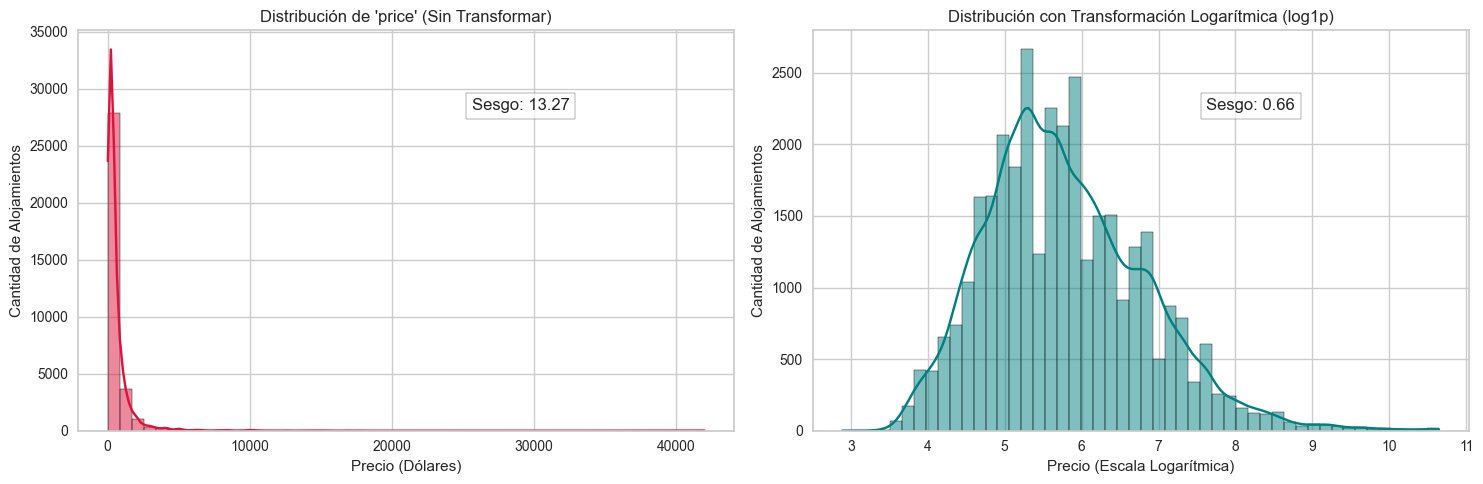

In [6]:
from src.plots.plots import graficar_comparacion_target

# Llamada a la función 
graficar_comparacion_target(df_clean, y_log, columna_target=target)


## **Variables numericas**

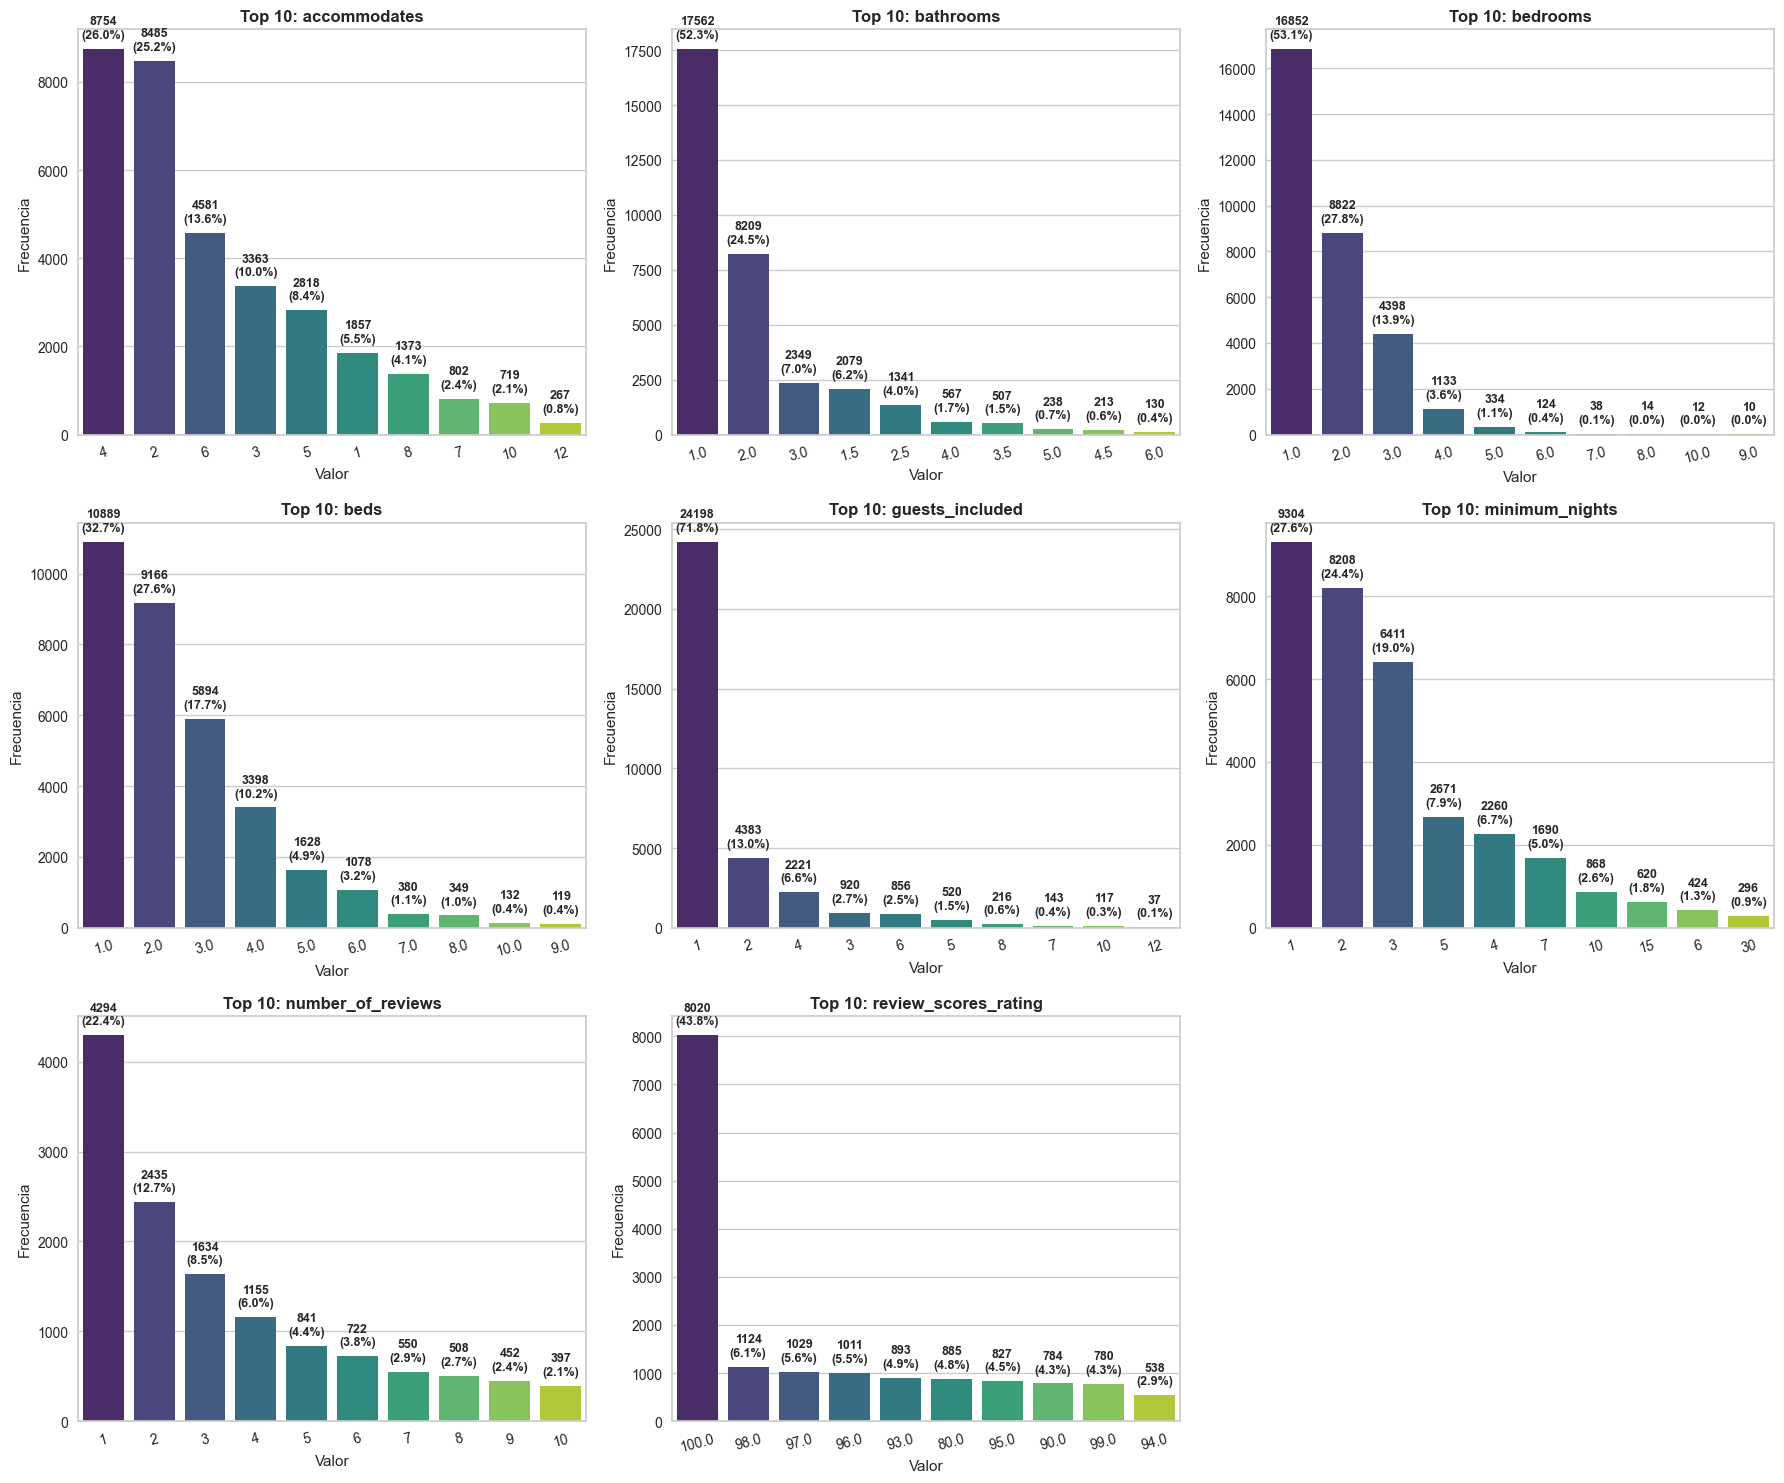

In [7]:
from src.plots.plots import graficar_top10_numericas

# grafica de frecuencias
graficar_top10_numericas(df_clean, columns=numeric_features)

## Resumen Estadístico

Las variables numéricas presentan distribuciones asimétricas positivas, con mayor concentración de observaciones en valores bajos y presencia de valores extremos altos.

En general:

- La mayoría de propiedades alojan entre 1 y 4 personas.
- Predominan propiedades con 1 o 2 habitaciones, baños y camas.
- `minimum_nights` se concentra en estancias cortas (1–3 noches).
- `number_of_reviews` muestra muchas propiedades con pocas reseñas.
- `review_scores_rating` se concentra en calificaciones altas.

### Conclusiones Técnicas

- Las distribuciones no son normales.
- Existen outliers y sesgo hacia la derecha.
- La mediana es más adecuada para imputación.
- Modelos basados en árboles como LightGBM o CatBoost son apropiados para este tipo de datos.

## **Variables binarias**

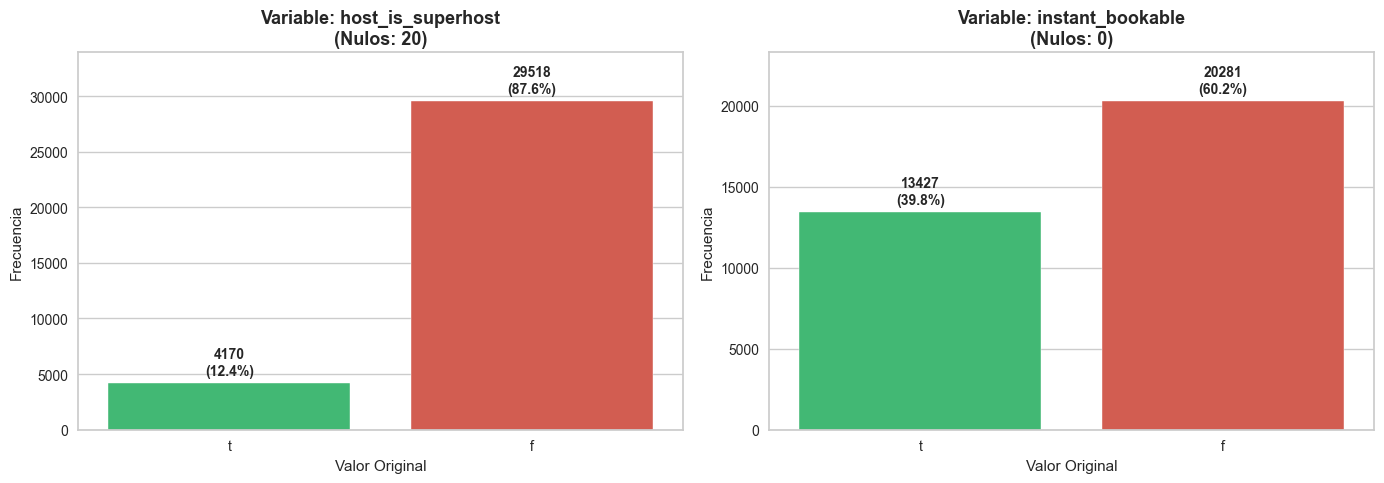

In [8]:

from src.plots.plots import visualizar_binarias
# graficas de barras
visualizar_binarias(df_clean, columnas_binarias=binary_features)

## Resumen Estadístico de Variables Binarias

Las variables categóricas binarias muestran una distribución desbalanceada hacia la categoría `f` (False).

- `host_is_superhost`:
  Solo aproximadamente el 12% de los hosts son superhosts, mientras que la gran mayoría no posee esta distinción.

- `instant_bookable`:
  Cerca del 40% de las propiedades permiten reserva instantánea, aunque predomina la opción no instantánea.

### Conclusiones Técnicas

- Existen distribuciones desbalanceadas entre categorías.
- `host_is_superhost` presenta pocos valores nulos.
- Estas variables pueden aportar valor predictivo importante al modelo al representar atributos de confianza y facilidad de reserva.

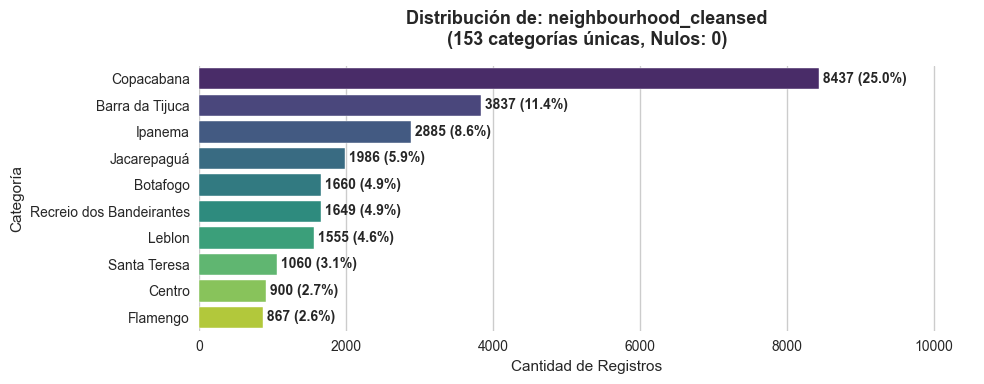

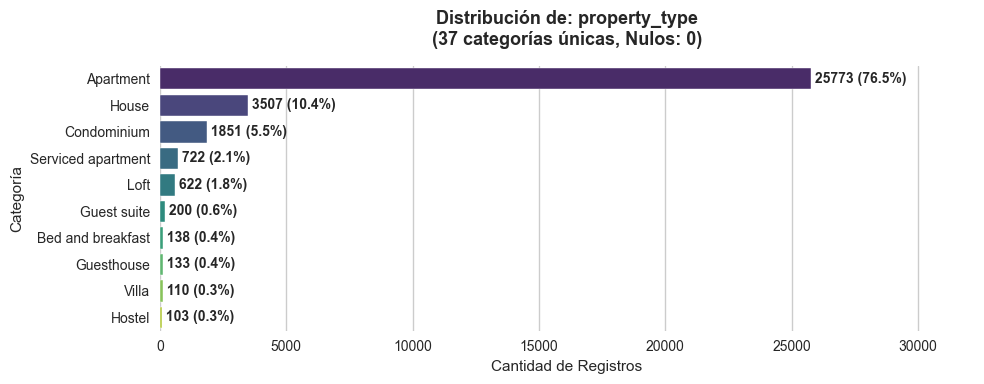

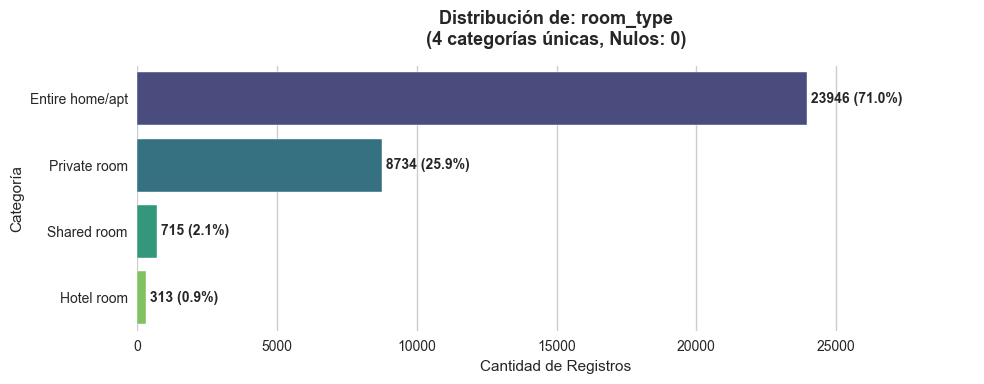

In [9]:

from src.plots.plots import visualizar_texto
# grafica de frecuencias en variables categoricas
visualizar_texto(df=df_clean, columnas_texto=text_features, top_n=10)

## Resumen Estadístico de Variables Categóricas

Las variables categóricas presentan distribuciones desbalanceadas, donde pocas categorías concentran gran parte de las observaciones.

- `neighbourhood_cleansed`:
  Existen 153 categorías únicas, predominando barrios como Copacabana, Barra da Tijuca e Ipanema.

- `property_type`:
  Los apartamentos representan ampliamente la categoría dominante (~76%).

- `room_type`:
  La mayoría de publicaciones corresponden a viviendas completas (~71%), seguidas por habitaciones privadas (~26%).

### Conclusiones Técnicas

- Existe alta cardinalidad en variables de ubicación.
- Las categorías están desbalanceadas.
- Variables como ubicación, tipo de propiedad y tipo de habitación son altamente relevantes para la predicción del precio.